# NUTDTS 816 Time Series Analysis
## Lab 0: Familiarisation (26 August 2026)

Goals: confirm Colab works, load a series with a DatetimeIndex, make a plot, save the notebook to your GitHub repository.

1. File > Save a copy in Drive.
2. Run the setup cell.
3. Run the data cell and the plot cell; change the plot to the log scale and run again.
4. Create a public GitHub repository named `nutdts816-<surname>`; File > Save a copy in GitHub.

In [3]:
# ---- Setup: run once per Colab session ----
# 1. Install the course libraries (about two minutes the first time)
!pip install -q statsmodels pmdarima statsforecast neuralforecast lightgbm arch plotly

# 2. Fetch the course data module and data snapshots from the course repository.
#    Replace REPO with your fork or the official course repository URL.
REPO = "https://github.com/PreciousFaseyosan/NUTDTS816-Time_Series_Analysis-_Course_Repository/raw/main"
import urllib.request, os
os.makedirs("data", exist_ok=True)
urllib.request.urlretrieve(f"{REPO}/src/tsdata.py", "tsdata.py")
DATA_FILES = ["nigeria_cpi", "nigeria_fx", "nigeria_grid", "nigeria_malaria", "nigeria_rainfall", "bonny_light", "daily_demand",
              "airpassengers", "a10", "h02", "ausbeer", "elecequip", "usmelec", "goog", "nile", "austourists", "oil", "dax", "uschange", "elecdemand"]
for f in DATA_FILES:
    urllib.request.urlretrieve(f"{REPO}/data/{f}.csv", f"data/{f}.csv")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
import tsdata
print("Setup complete.")

Setup complete.


In [11]:
ap = tsdata.airpassengers()
print(type(ap), ap.index.freq)
ap.head(15)

<class 'pandas.core.series.Series'> <MonthBegin>


,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


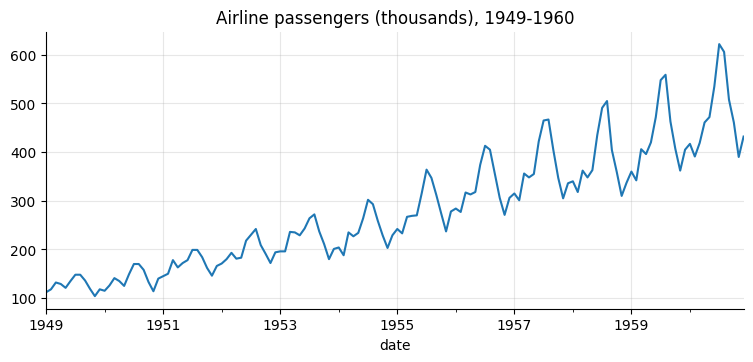

In [7]:
ax = ap.plot(title='Airline passengers (thousands), 1949-1960')

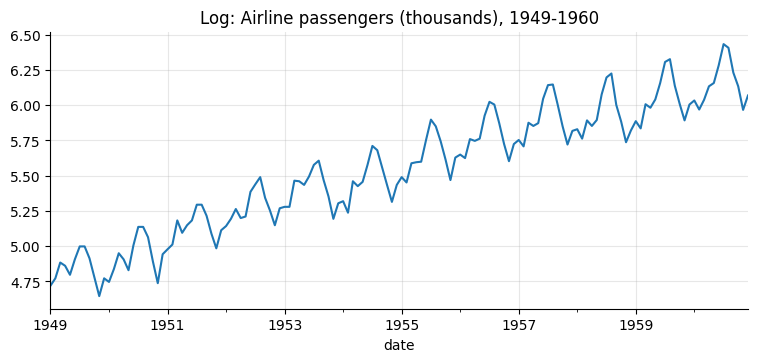

In [9]:
ax = np.log(ap).plot(title='Log: Airline passengers (thousands), 1949-1960')

In [12]:
cpi = tsdata.nigeria_cpi(); fx = tsdata.nigeria_fx(); grid = tsdata.nigeria_grid()
pd.concat([cpi, fx, grid], axis=1).tail(20)

,cpi,ngn_usd,generation_mw
date,,,
2024-12-01,113.9088,1553.2540,3776.9
2025-01-01,110.6800,1535.4445,3924.7
2025-02-01,112.9392,1500.4716,4211.3
2025-03-01,117.3400,1525.8693,4529.6
2025-04-01,119.5200,1594.5515,4097.2
2025-05-01,121.3500,1594.7047,4220.4
2025-06-01,123.3907,1549.2943,3152.8
2025-07-01,125.8500,1529.8470,3817.2
2025-08-01,126.7865,1534.2498,3911.3


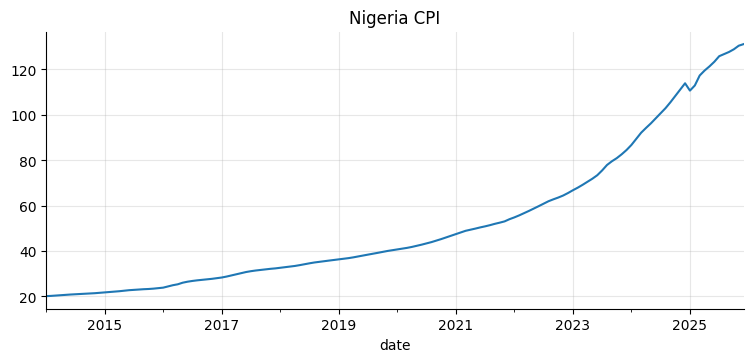

In [14]:
ax = cpi.plot(title='Nigeria CPI')

## Self-check (ungraded)

1. What is the seasonal period m of monthly CPI? Of daily electricity demand?
2. Write one sentence on what the CPI plot shows after mid-2023.
3. In your own words: why can you not use random k-fold cross-validation on a time series?

## Self-check Answers

1. m = 12 for CPI. m = 7 for daily electricity demand (This is because electricity demand follows a weekly rythm - weekday usage differs from weekend usage for factories/homes)
2. After mid 2023, the CPI started to increase steeply.
3. Because time series data are dependent. A random k-fold cross-validation assumes data to be independent and identically distributed.